In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import string
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from wordcloud import WordCloud

In [4]:
df = pd.read_csv("sentiment_dataset.csv")

df.head()

,text,sentiment
0,I experienced this emotion when my grandfather...,sadness
1,"when I first moved in , I walked everywhere ....",neutral
2,"` Oh ! "" she bleated , her voice high and rath...",anger
3,"However , does the right hon. Gentleman recogn...",fear
4,My boyfriend didn't turn up after promising th...,sadness


In [5]:
sentiment_map = {
    'joy': 'positive',
    'neutral': 'neutral',
    'sadness': 'negative',
    'anger': 'negative',
    'fear': 'negative'
}

df['sentiment3'] = df['sentiment'].map(sentiment_map)

In [6]:

df.shape

df.info()

df.isnull().sum()

df['sentiment3'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11327 entries, 0 to 11326
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        11327 non-null  object
 1   sentiment   11327 non-null  object
 2   sentiment3  11327 non-null  object
dtypes: object(3)
memory usage: 265.6+ KB


sentiment3
negative    6747
positive    2326
neutral     2254
Name: count, dtype: int64

In [7]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_text'])

y = df['sentiment3']

TF-IDF converts text into numerical vectors by assigning higher weights to important words that appear frequently in a document but less frequently across all documents. This representation helps machine learning algorithms identify informative features for sentiment classification.

In [9]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train,y_train)

pred_nb = nb.predict(X_test)

In [11]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

print("Accuracy of Naive Bayes:",accuracy_score(y_test,pred_nb))

print(classification_report(y_test,pred_nb))

Accuracy of Naive Bayes: 0.7118270079435128
              precision    recall  f1-score   support

    negative       0.70      0.98      0.82      1350
     neutral       0.72      0.30      0.43       451
    positive       0.88      0.32      0.47       465

    accuracy                           0.71      2266
   macro avg       0.77      0.53      0.57      2266
weighted avg       0.74      0.71      0.67      2266



In [14]:
print("Accuracy of Logistic Regression:",accuracy_score(y_test,pred_lr))

print(classification_report(y_test,pred_lr))

Accuracy of Logistic Regression: 0.8031774051191527
              precision    recall  f1-score   support

    negative       0.80      0.95      0.87      1350
     neutral       0.77      0.69      0.73       451
    positive       0.84      0.50      0.63       465

    accuracy                           0.80      2266
   macro avg       0.81      0.71      0.74      2266
weighted avg       0.81      0.80      0.79      2266



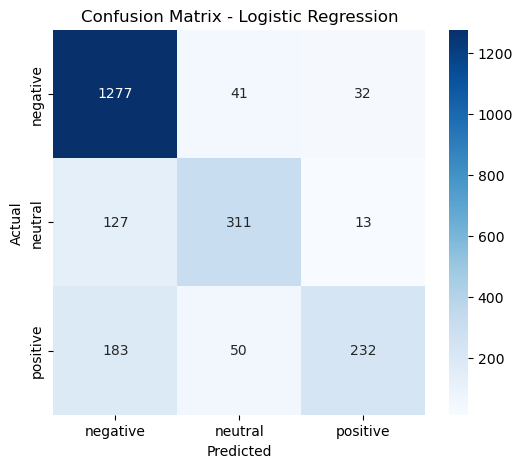

In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['negative','neutral','positive'],
    yticklabels=['negative','neutral','positive']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

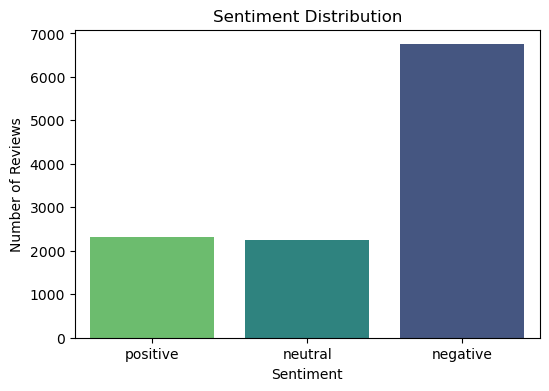

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='sentiment3',
    hue='sentiment3',
    order=['positive', 'neutral', 'negative'],
    palette='viridis',
    legend=False
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

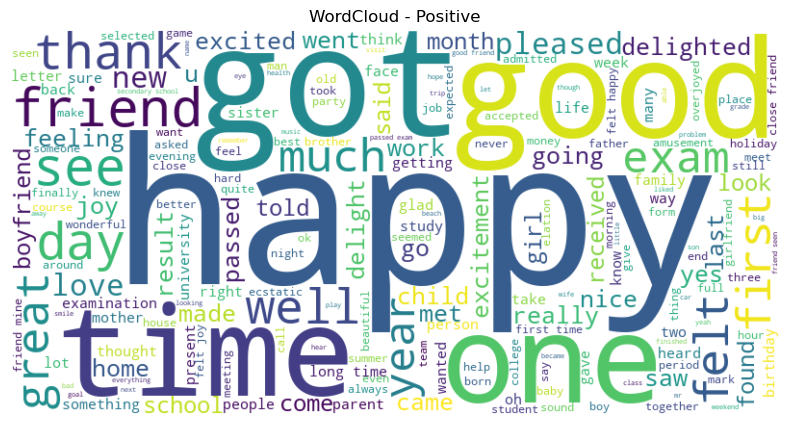

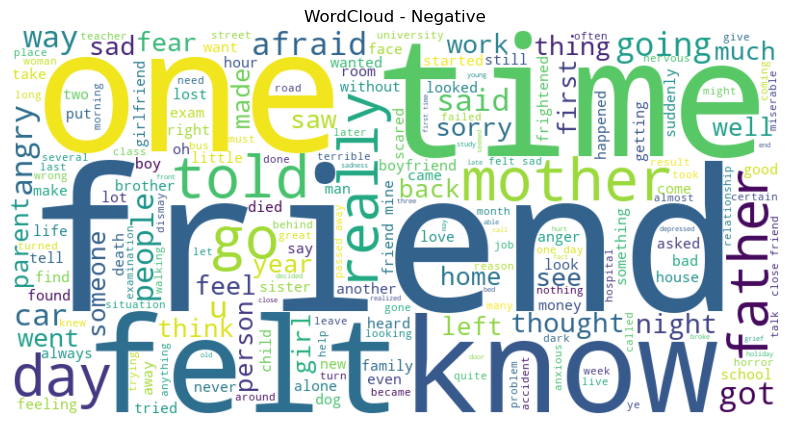

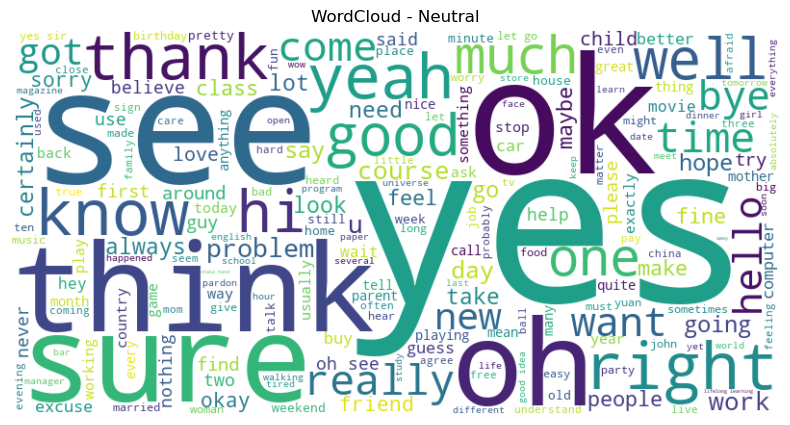

In [21]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

sentiments = ['positive', 'negative', 'neutral']

for sentiment in sentiments:

    text = " ".join(
        df[df['sentiment3'] == sentiment]['clean_text']
        .dropna()
        .astype(str)
    )

    if text.strip():

        wc = WordCloud(
            width=800,
            height=400,
            background_color='white'
        ).generate(text)

        plt.figure(figsize=(10,5))
        plt.imshow(wc, interpolation='bilinear')
        plt.axis("off")
        plt.title(f"WordCloud - {sentiment.capitalize()}")
        plt.show()

In [17]:
results = df.loc[y_test.index].copy()

results["Actual"] = y_test

results["Predicted"] = pred_lr

errors = results[
    results["Actual"] != results["Predicted"]
]

errors[['text','Actual','Predicted']].head(5)

,text,Actual,Predicted
4767,"Yeah , I am very impressed with Tom Hanks ' p...",positive,neutral
2973,That ’ s smart . What do you usually do to re...,positive,negative
1148,When I won an unexpected sum of money.,positive,negative
5368,What's wrong with him ?,neutral,negative
7795,I hear that you've been to the Saikei Ski Reso...,neutral,positive


Discuss reasons such as:

Mixed sentiment in one sentence
Ambiguous wording
Negation (e.g., "not bad")
Short text lacking context
Emotion words used sarcastically

Logistic Regression achieved higher accuracy and F1-score than Naive Bayes, making it the better-performing model for this dataset. The TF-IDF representation effectively captured important textual features for sentiment classification. Such models can be applied to analyze customer reviews, social media posts, product feedback, hotel reviews, movie reviews, and support tickets to understand public opinion and improve business decision-making.